# Bagging Ensemble vs Random Forest

Both **Bagging** and **Random Forest** are ensemble methods that build multiple Decision Trees on bootstrapped subsets of the training data and aggregate their predictions. The key distinction lies in how each tree is constructed:

| Property | Bagging | Random Forest |
|---|---|---|
| Bootstrap sampling | Yes | Yes |
| Feature subsampling per split | No — all features considered | Yes — random subset of features |
| Tree correlation | Higher (trees can be similar) | Lower (trees are more diverse) |
| Variance reduction | Moderate | Stronger |

By randomly restricting the features available at each split, Random Forest forces trees to be less correlated with one another. This additional decorrelation typically yields better generalization than plain Bagging.

In [32]:
from sklearn.datasets import make_classification
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import plot_tree
import pandas as pd
import matplotlib.pyplot as plt

### Generate Dataset

We use `make_classification` to generate a small synthetic binary classification problem.

Key parameters used:
- `n_features=5` — total number of input features
- `n_informative=5` — all 5 features carry signal (no noise features)
- `n_redundant=0` — no features are linear combinations of others
- `n_clusters_per_class=1` — each class forms a single cluster in feature space

In [11]:
X,y = make_classification(n_features=5,n_informative= 5,n_clusters_per_class=1,n_redundant=0,)
data = pd.DataFrame(X,columns=['col_1','col_2','col_3','col_4','col_5'])
data['target'] = y
data.head(2)

,col_1,col_2,col_3,col_4,col_5,target
0,0.150266,2.446888,0.558447,-1.751886,1.878035,0
1,-2.340311,2.076627,2.904143,1.701680,0.559317,0


## Bagging Ensemble

**BaggingClassifier** trains each base estimator (a Decision Tree by default) on a different bootstrap sample of the training data. At every split inside a tree, the algorithm is free to search across **all** features to find the best split.

Key parameters used here:
- `n_estimators=500` — number of trees in the ensemble; more trees generally reduce variance but increase training time
- `max_features=2` — limits the number of features drawn **per tree** (i.e., each tree sees only 2 features in total); however, within that tree each node still evaluates both available features at each split

In [13]:
bagging = BaggingClassifier(max_features=2,n_estimators=500)
bagging.fit(data.iloc[:,0:5],data.iloc[:,-1])

BaggingClassifier(max_features=2, n_estimators=500)

### Decision Tree from the Bagging Ensemble

We visualise the **first** tree in the Bagging ensemble (`estimators_[0]`).

Because Bagging does not restrict features at the individual **split** level, trees can grow deep and become highly adapted to their bootstrap sample. Notice that the tree may not use all 5 features, but it could in principle use any of the 2 features it was given at every node.

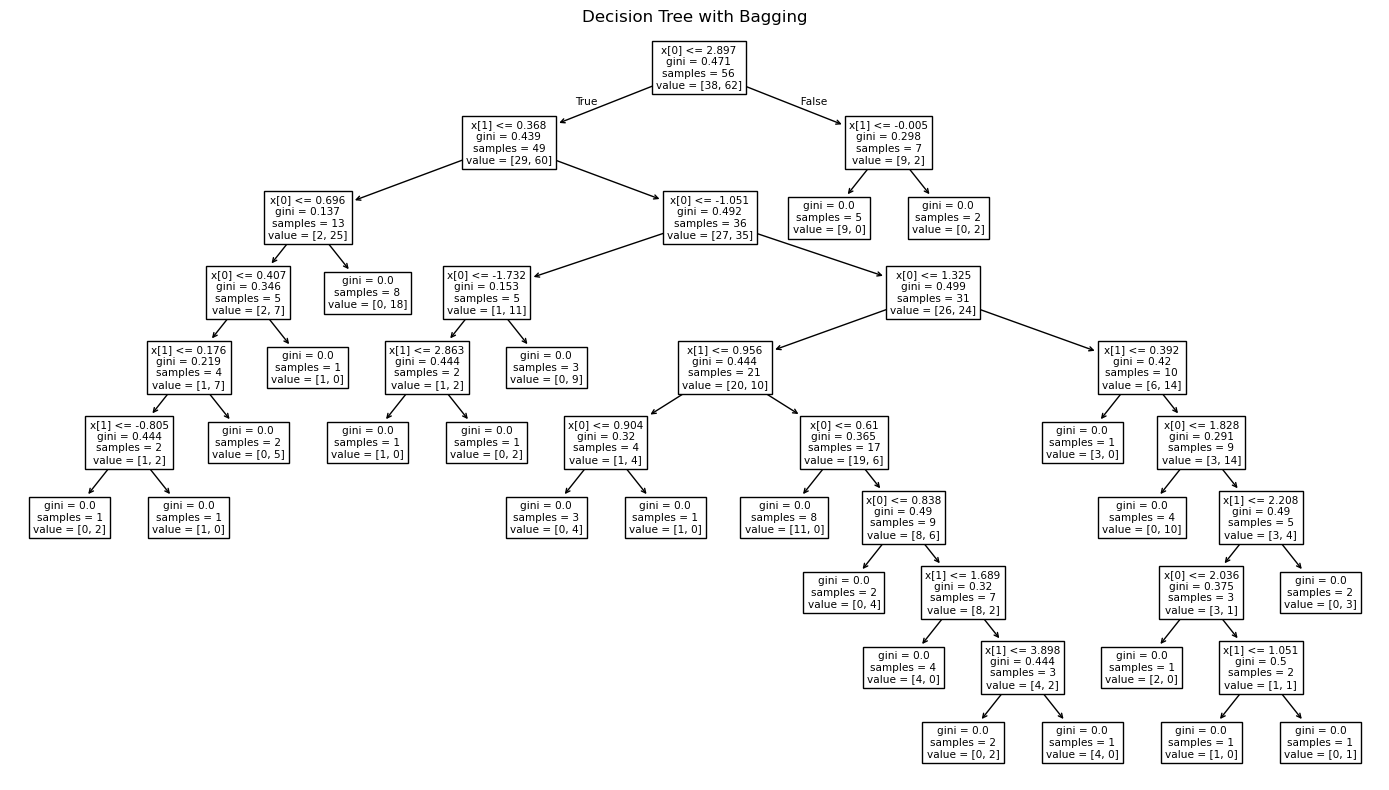

In [15]:
plt.figure(figsize=(14,8))
plot_tree(bagging.estimators_[0])
plt.title("Decision Tree with Bagging")
plt.tight_layout()
plt.show()

## Random Forest

**RandomForestClassifier** extends Bagging by adding **feature randomness at every individual split**. When deciding how to partition the data at each node, the algorithm considers only a random subset of features (controlled by `max_features`). This additional constraint:

1. **Decorrelates trees** — even trees trained on similar bootstrap samples diverge in structure.
2. **Reduces overfitting** — no single dominant feature can drive every tree.
3. **Improves generalisation** — lower variance compared to plain Bagging.

Key parameters used here:
- `n_estimators=500` — same number of trees as Bagging for a fair comparison
- `max_features=2` — at **each split**, only 2 randomly chosen features are evaluated (not just per tree)

In [17]:
random_forest = RandomForestClassifier(max_features=2,n_estimators=500)
random_forest.fit(data.iloc[:,0:5],data.iloc[:,-1])

RandomForestClassifier(max_features=2, n_estimators=500)

### Decision Tree from the Random Forest

We visualise the **fifth** tree (`estimators_[4]`) from the Random Forest. Compared to the Bagging tree, this tree is likely shallower and uses different split combinations — a direct consequence of the per-split feature restriction preventing any single dominant feature from monopolising the tree structure.

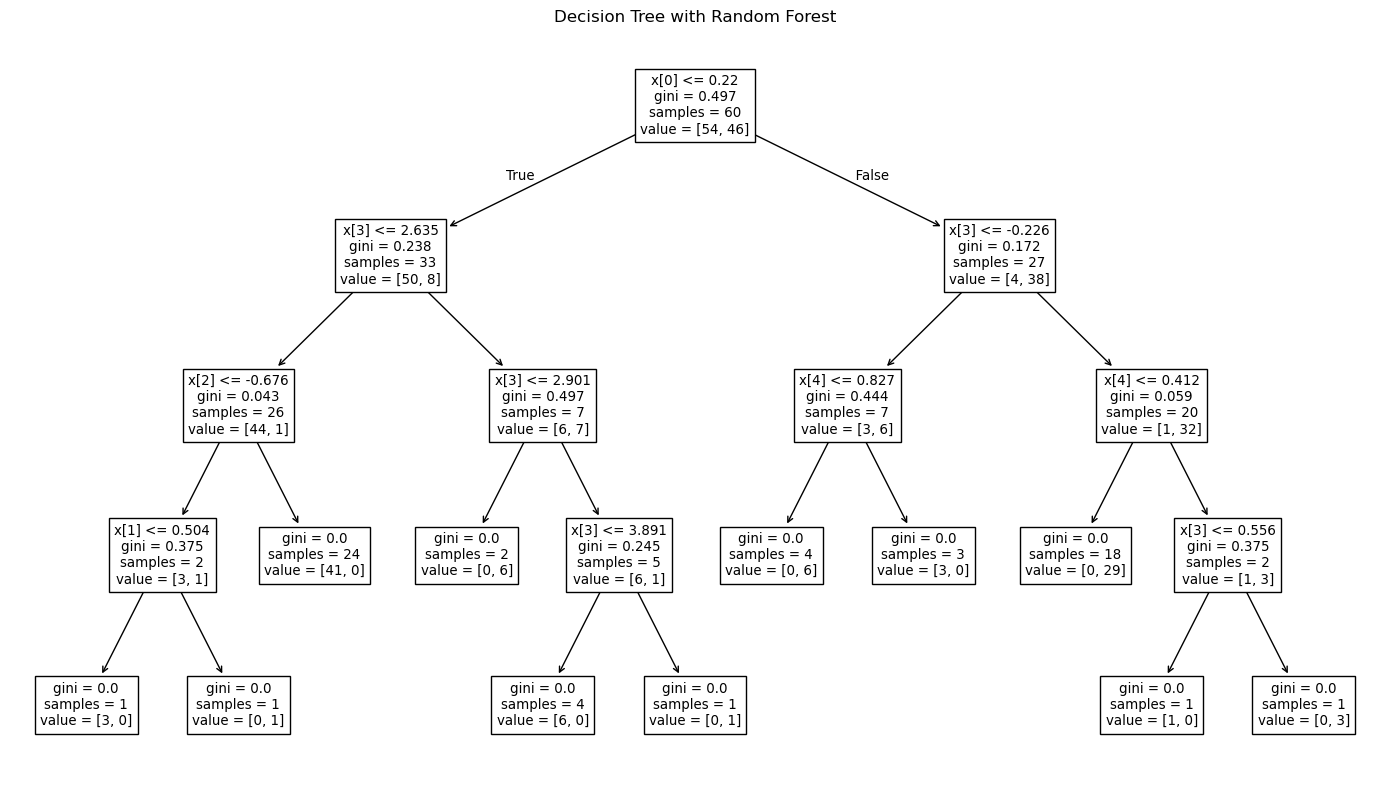

In [19]:
plt.figure(figsize=(14,8))
plot_tree(random_forest.estimators_[4])
plt.title("Decision Tree with Random Forest")
plt.tight_layout()
plt.show()

### Accuracy Comparision 

In [30]:
X_train, X_test, y_train, y_test = train_test_split(data.iloc[:, 0:5], data.iloc[:, -1], test_size=0.2, random_state=42)
bagging_cmp = BaggingClassifier(max_features=2, n_estimators=500, random_state=42)
bagging_cmp.fit(X_train, y_train)
rf_cmp = RandomForestClassifier(max_features=2, n_estimators=500, oob_score=True, random_state=42)
rf_cmp.fit(X_train, y_train)

# Evaluate on the unseen test set
bagging_acc = accuracy_score(y_test, bagging_cmp.predict(X_test))
rf_acc      = accuracy_score(y_test, rf_cmp.predict(X_test))
print(f"Bagging Accuracy       : {bagging_acc:.4f}")
print(f"Random Forest Accuracy : {rf_acc:.4f}")
print(f"Random Forest OOB Score: {rf_cmp.oob_score_:.4f}")

Bagging Accuracy       : 0.9000
Random Forest Accuracy : 0.9000
Random Forest OOB Score: 0.9250


### Feature Importance Graph  

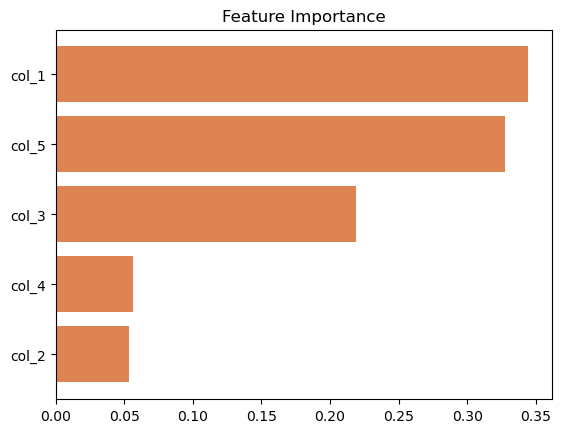

In [37]:
feature_names = ['col_1', 'col_2', 'col_3', 'col_4', 'col_5']
importances   = random_forest.feature_importances_
sorted_idx = importances.argsort()
plt.barh([feature_names[i] for i in sorted_idx],importances[sorted_idx],color='#DD8452')
plt.title("Feature Importance")
plt.show()